In [1]:
!pip install aeon
!mkdir -p data
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_MTSC_TRAIN.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_MTSC_TEST.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_UTSC_TRAIN.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_UTSC_TEST.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_MTSER_TRAIN.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_MTSER_TEST.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_UTSER_TRAIN.ts -P data/
!wget -nc https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_UTSER_TEST.ts -P data/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 65.8 MB/s eta 0:00:00
--2026-09-11 16:18:40--  https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_MTSC_TRAIN.ts
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 367415 (359K) [text/plain]
Saving to: ‘data/KDD_MTSC_TRAIN.ts’

KDD_MTSC_TRAIN.ts   100%[===================>] 358.80K  --.-KB/s    in 0.009s  

2026-09-11 16:18:40 (38.2 MB/s) - ‘data/KDD_MTSC_TRAIN.ts’ saved [367415/367415]

--2026-09-11 16:18:40--  https://raw.githubusercontent.com/aeon-tutorials/KDD-2024/main/Notebooks/data/KDD_MTSC_TEST.ts
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubus

In [2]:
# There are some deprecation warnings present in the notebook, we will ignore them.
# Remove this cell if you are interested in finding out what is changing soon, for
# aeon there will be big changes in out v1.0.0 release!
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

Давайте сначала сделаем импорт и загрузим наборы данных (это может занять некоторое время, если вы импортируете их впервые!):

In [4]:
import numpy as np
from aeon.datasets import load_classification
from aeon.transformations.collection.shapelet_based import (
    RandomShapeletTransform,
)
from aeon.classification.shapelet_based import (
    ShapeletTransformClassifier,
    RDSTClassifier,
)
from aeon.testing.data_generation import make_example_3d_numpy
from pathlib import Path
from aeon.datasets import load_from_ts_file

## Упражнения  

1. Выбрать и скачать один из наборов данных с сайта [timeseriesclassification](https://www.timeseriesclassification.com/dataset.php).

    Подробнее о датасетах, их форматах, и как их скачивать - [Ноутбук](https://github.com/aeon-toolkit/aeon/blob/main/examples/datasets/data_loading.ipynb)

2.  Записать название выбранного датасета в таблицу. Помните - совпадений быть не должно. Каждый работает с уникальным датасетом. Этот датасет вам понадобиться в лабе 14 (aeon) и лабе 16 (tslean)

3. Проанализировать датасет

4. Найти шейплеты для классов в датесете

5. Провести классификацию на основе шейплетов.

**Упражнения:**

In [6]:
import numpy as np
from aeon.datasets import load_classification

X, y = load_classification('Beef') # Взял Beef

print(f"Общее количество примеров (временных рядов): {len(X)}")
print(f"Количество классов: {len(np.unique(y))}")
print(f"Названия классов: {np.unique(y)}")

unique, counts = np.unique(y, return_counts=True)
print("\nРаспределение по классам:")
for cls, cnt in zip(unique, counts):
    print(f"  Класс '{cls}': {cnt} примеров ({cnt/len(y)*100:.1f}%)")

print(f"\nФорма данных одного примера: {X[0].shape}")

Общее количество примеров (временных рядов): 60
Количество классов: 5
Названия классов: ['1' '2' '3' '4' '5']

Распределение по классам:
  Класс '1': 12 примеров (20.0%)
  Класс '2': 12 примеров (20.0%)
  Класс '3': 12 примеров (20.0%)
  Класс '4': 12 примеров (20.0%)
  Класс '5': 12 примеров (20.0%)

Форма данных одного примера: (1, 470)


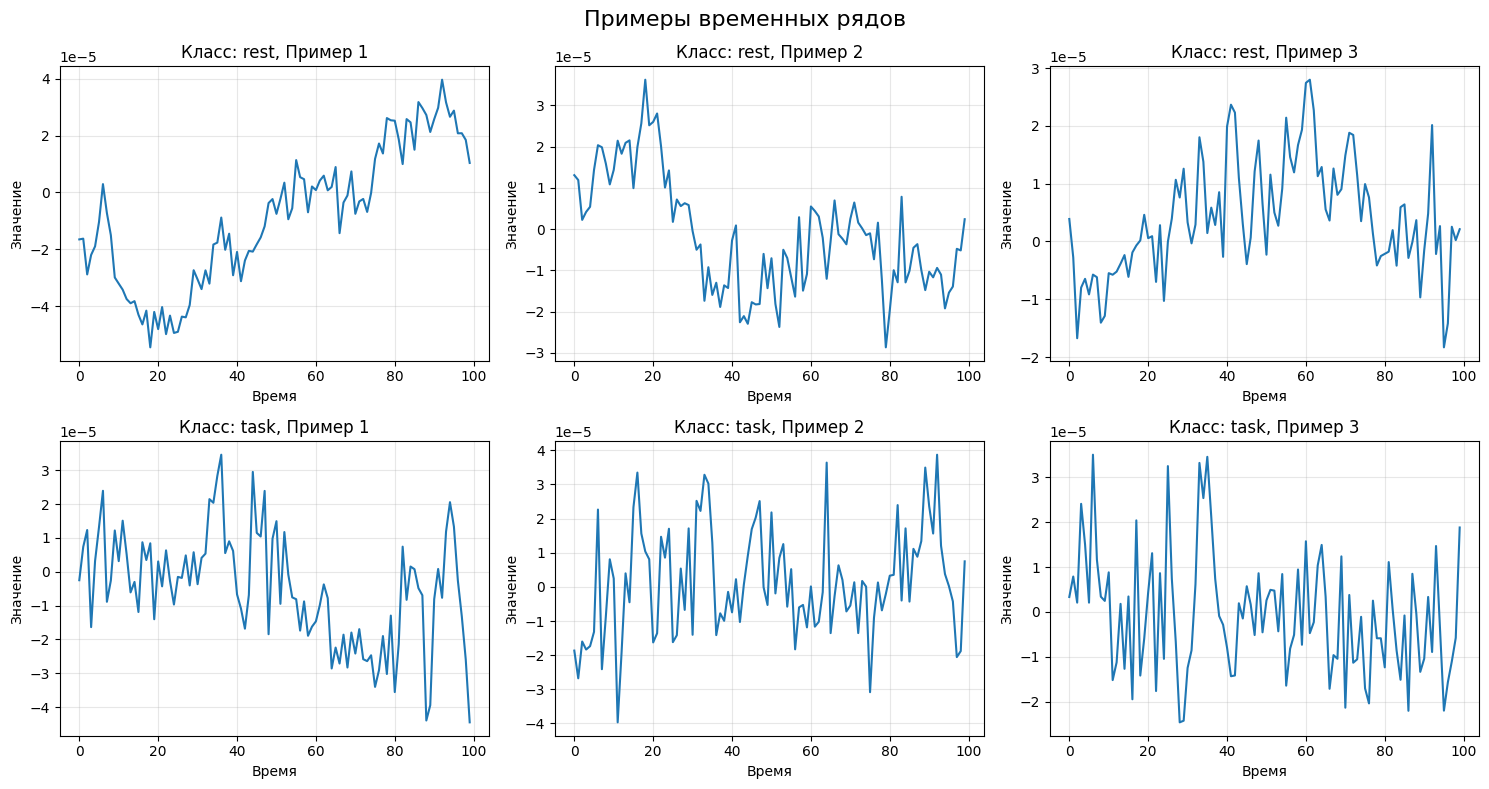

Основные статистики для каждого канала измерения:

Канал 0:
  Среднее: 0.0000
  Стандартное отклонение: 0.0000
  Минимум: -0.0001
  Максимум: 0.0001


In [7]:
import numpy as np
import matplotlib.pyplot as plt

X = X_train if 'X_train' in globals() else X
y = y_train if 'y_train' in globals() else y

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Примеры временных рядов', fontsize=16)

for i, class_label in enumerate(np.unique(y)):
    class_indices = np.where(y == class_label)[0][:3]

    for j, idx in enumerate(class_indices):
        ax = axes[i, j]

        for channel in range(X[idx].shape[0]):
            ax.plot(X[idx][channel], linewidth=1.5)
        ax.set_title(f'Класс: {class_label}, Пример {j+1}')
        ax.set_xlabel('Время')
        ax.set_ylabel('Значение')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Основные статистики для каждого канала измерения:")
for channel in range(X[0].shape[0]):
    channel_data = np.concatenate([x[channel] for x in X])
    print(f"\nКанал {channel}:")
    print(f"  Среднее: {np.mean(channel_data):.4f}")
    print(f"  Стандартное отклонение: {np.std(channel_data):.4f}")
    print(f"  Минимум: {np.min(channel_data):.4f}")
    print(f"  Максимум: {np.max(channel_data):.4f}")

In [8]:
from aeon.classification.shapelet_based import ShapeletTransformClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

stc = ShapeletTransformClassifier(
    n_shapelet_samples=1000,
    max_shapelets=50,
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42
)

stc.fit(X_train, y_train)

y_pred = stc.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nТочность классификации на тестовой выборке: {accuracy:.3f}")


Точность классификации на тестовой выборке: 0.917


[<Figure size 1600x950 with 4 Axes>]

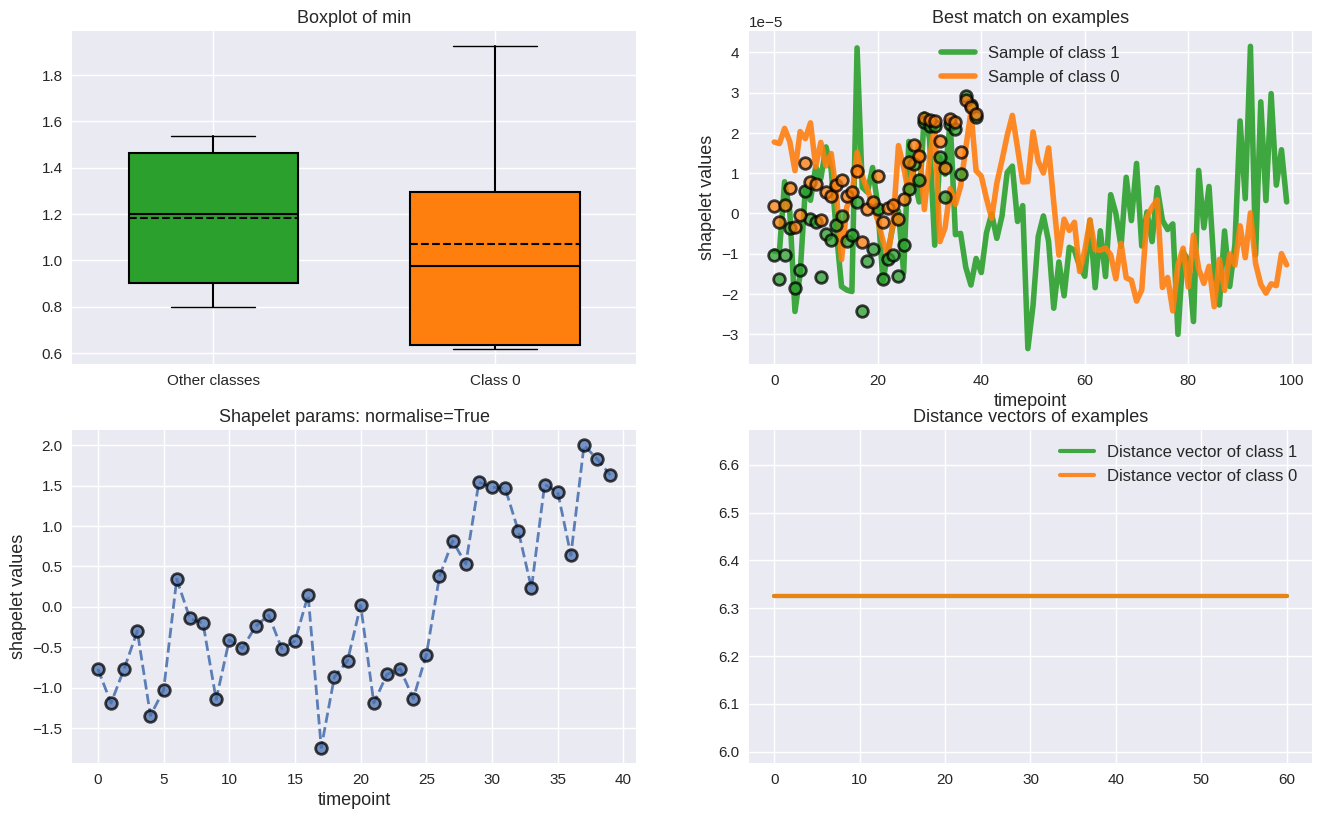

In [10]:
from aeon.visualisation import ShapeletClassifierVisualizer

stc_vis = ShapeletClassifierVisualizer(stc)

stc_vis.visualize_shapelets_one_class(
    X_test,
    y_test,
    0,
    figure_options={"figsize": (16,9.5), "nrows": 2, "ncols": 2},
    scatter_options={"s": 70,"alpha": 0.75,"zorder": 3,"edgecolor": "black","linewidths": 2},
    rc_Params_options={
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
},
)

[<Figure size 1600x950 with 4 Axes>]

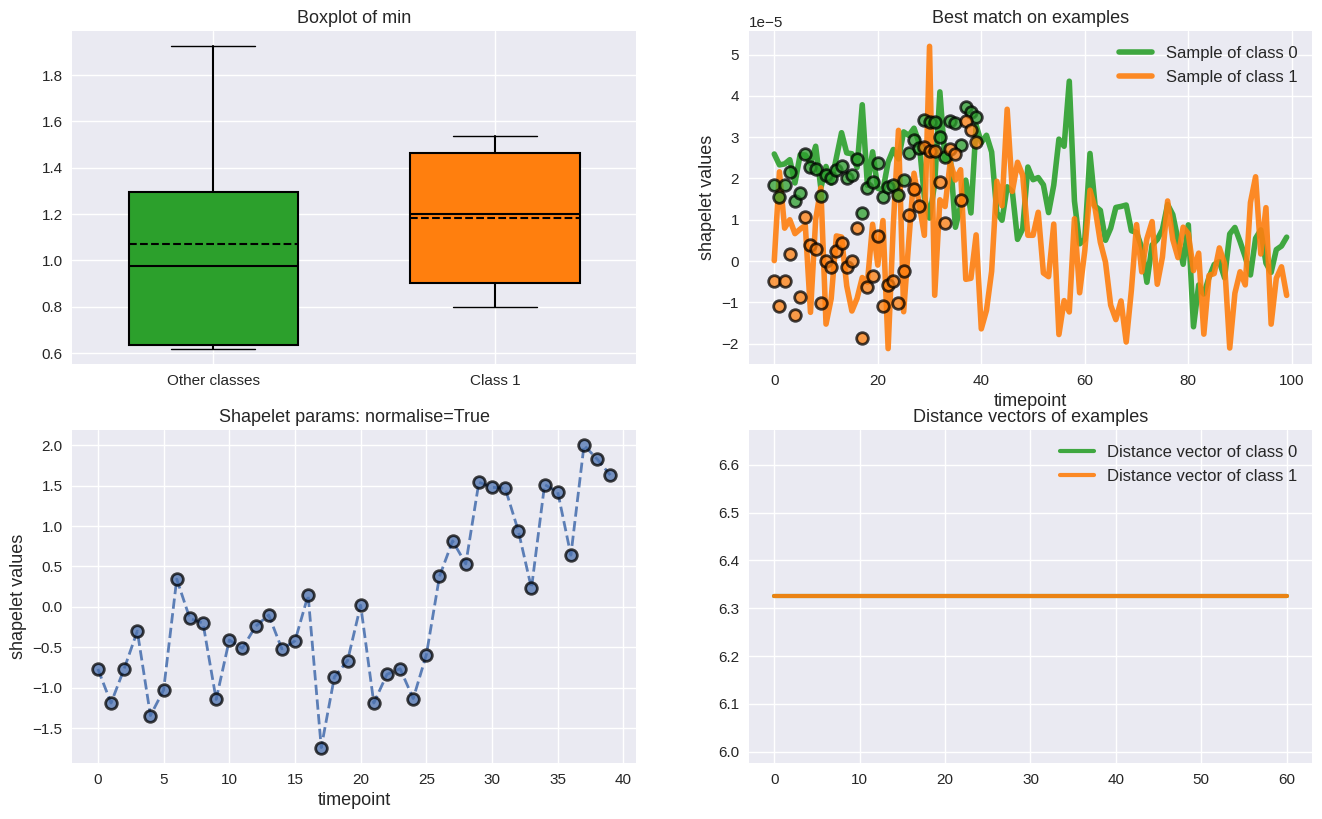

In [11]:
stc_vis = ShapeletClassifierVisualizer(stc)

stc_vis.visualize_shapelets_one_class(
    X_test,
    y_test,
    1,
    figure_options={"figsize": (16,9.5), "nrows": 2, "ncols": 2},
    scatter_options={"s": 70,"alpha": 0.75,"zorder": 3,"edgecolor": "black","linewidths": 2},
    rc_Params_options={
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
},
)

In [12]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(cm)

              precision    recall  f1-score   support

        rest       0.86      1.00      0.92         6
        task       1.00      0.83      0.91         6

    accuracy                           0.92        12
   macro avg       0.93      0.92      0.92        12
weighted avg       0.93      0.92      0.92        12

Матрица ошибок:
[[6 0]
 [1 5]]


In [13]:
rdst = RDSTClassifier().fit(
    X_train, y_train
)

y_pred = rdst.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность классификации на тестовой выборке : {accuracy:.3f}")

Точность классификации на тестовой выборке : 1.000


/usr/local/lib/python3.13/dist-packages/aeon/visualisation/estimator/_shapelets.py:761: UserWarning: Shapelet importance ranking may be unreliable when using linear classifiers with RDST. This is due to the interaction between argmin and shapelet occurrence features, which can distort the rankings. Consider evaluating the results carefully or using an alternative method.
  warnings.warn(


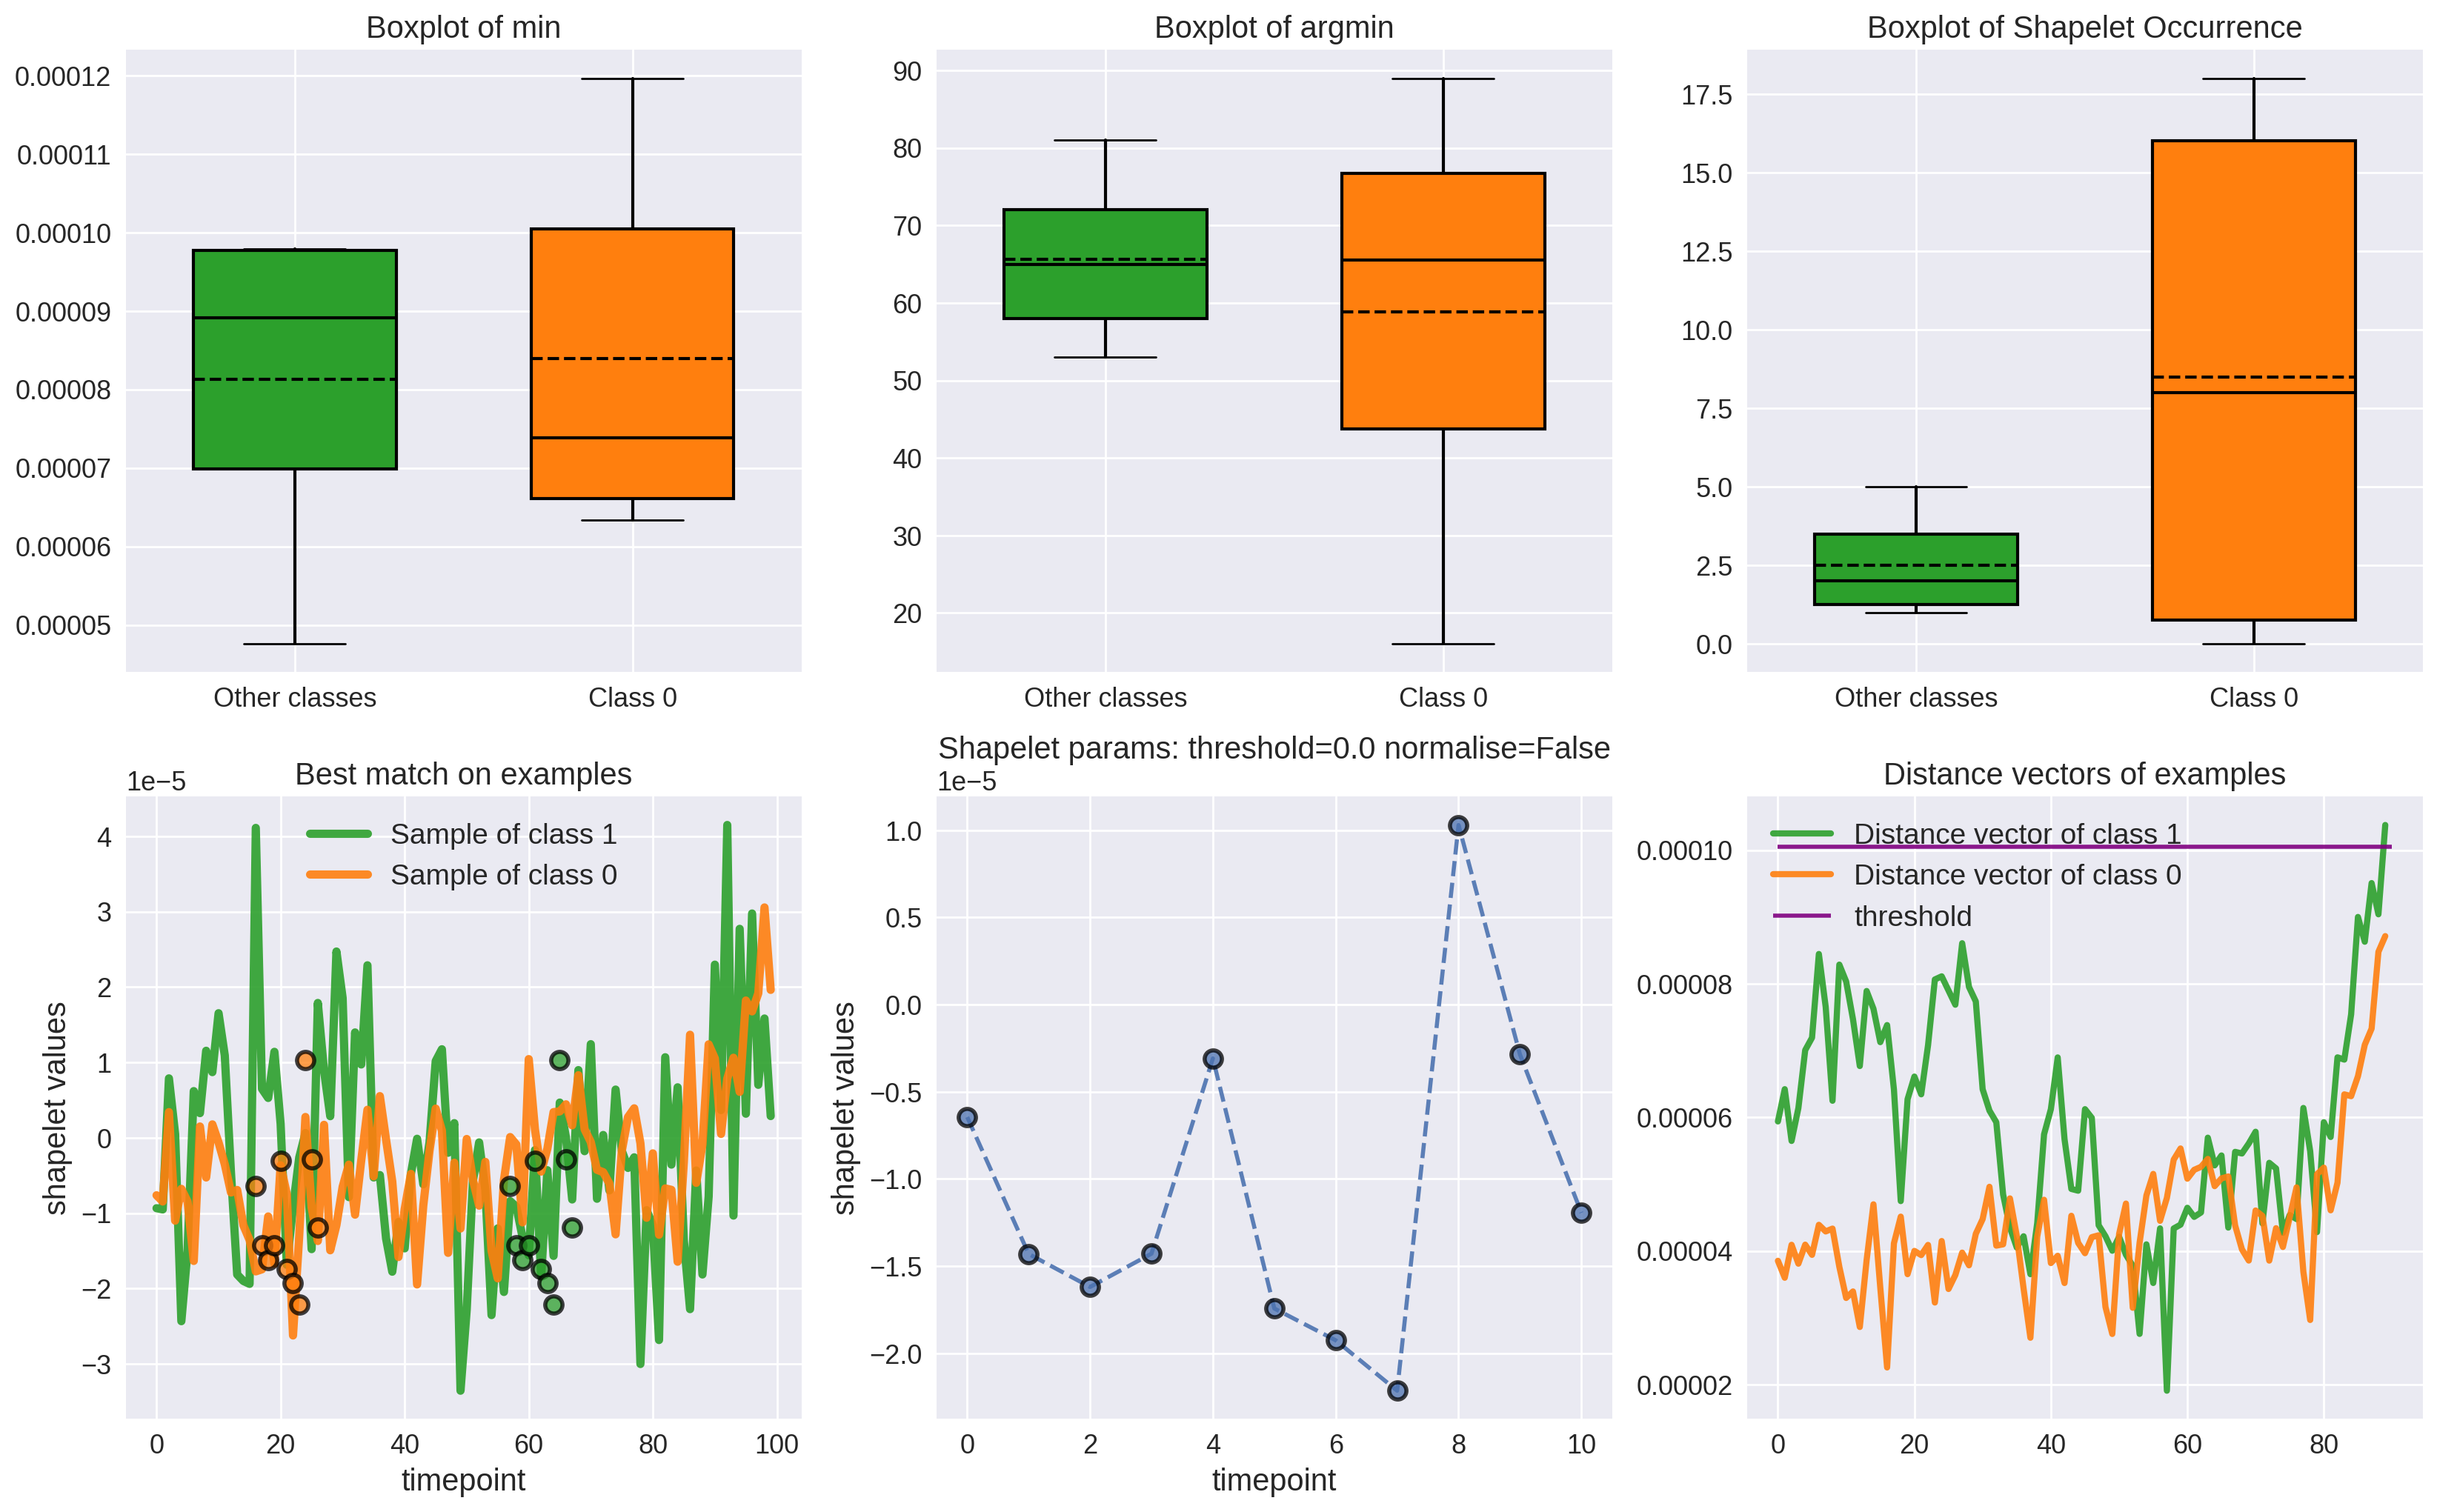

In [14]:
rdst_vis = ShapeletClassifierVisualizer(rdst)

fig = rdst_vis.visualize_shapelets_one_class(
    X_test,
    y_test,
    0,
    scatter_options={"s": 70,"alpha": 0.75,"zorder": 3,"edgecolor": "black","linewidths": 2},
)

/usr/local/lib/python3.13/dist-packages/aeon/visualisation/estimator/_shapelets.py:761: UserWarning: Shapelet importance ranking may be unreliable when using linear classifiers with RDST. This is due to the interaction between argmin and shapelet occurrence features, which can distort the rankings. Consider evaluating the results carefully or using an alternative method.
  warnings.warn(


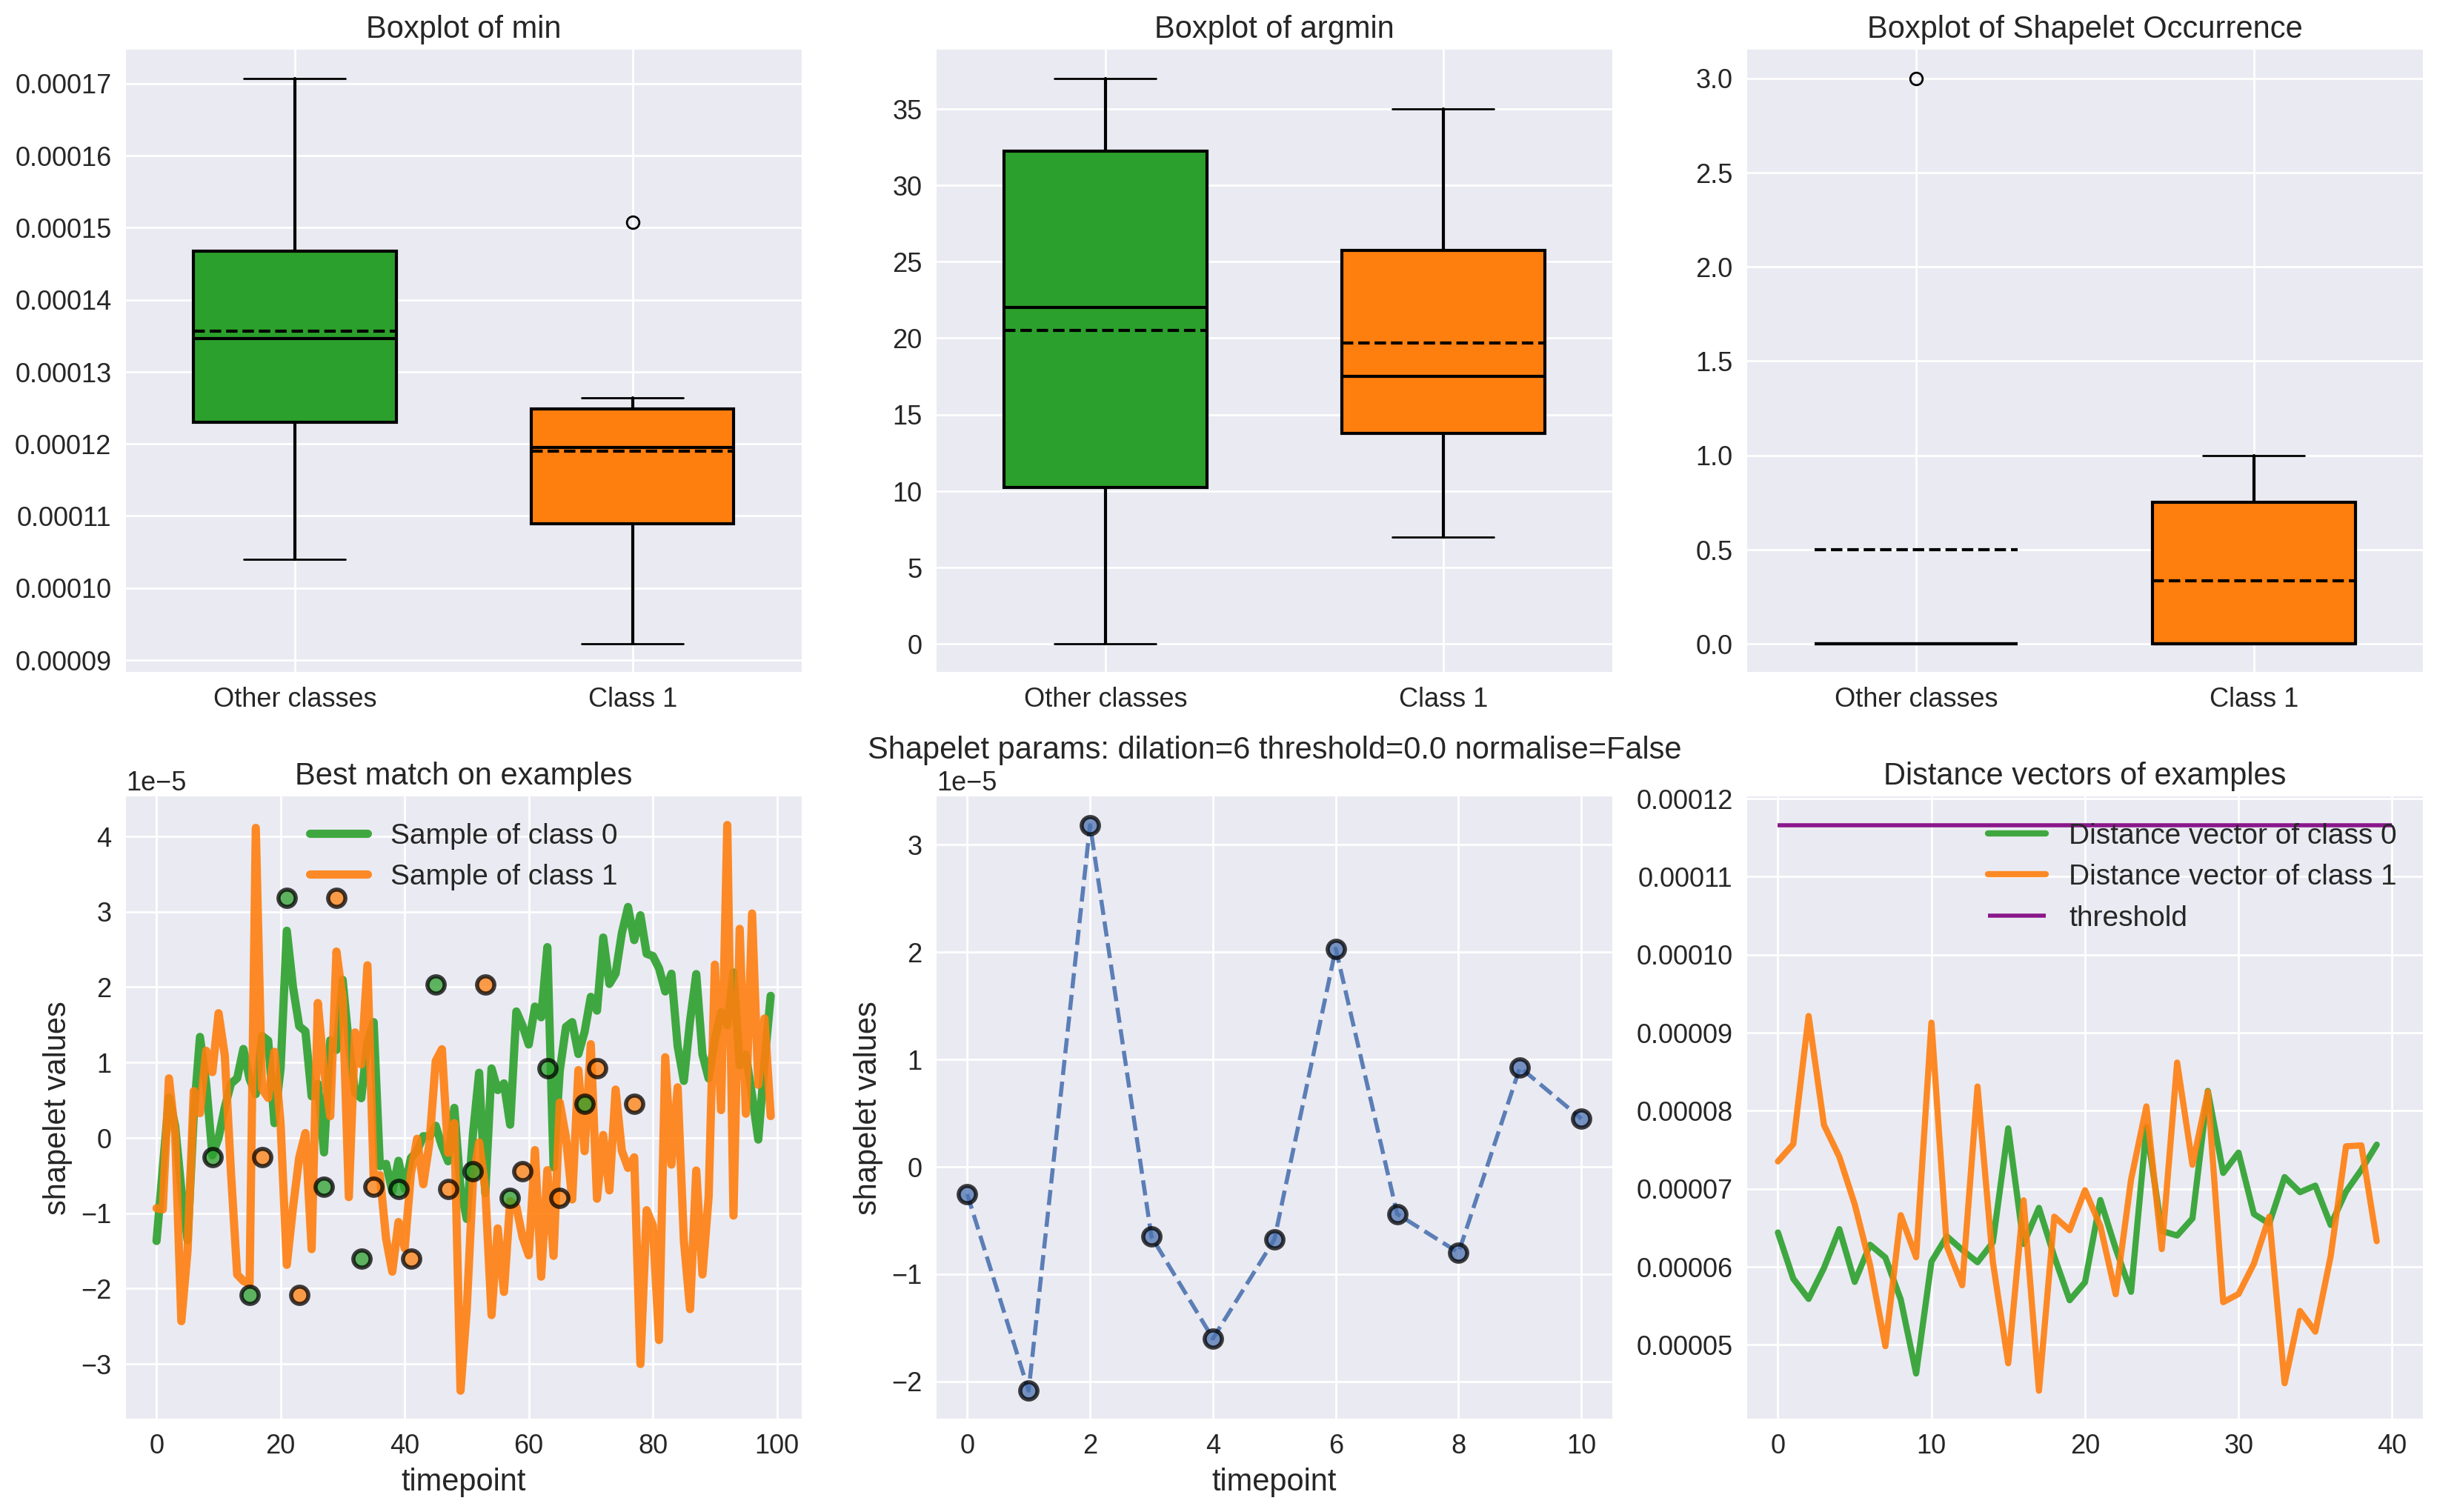

In [15]:
rdst_vis = ShapeletClassifierVisualizer(rdst)

fig = rdst_vis.visualize_shapelets_one_class(
    X_test,
    y_test,
    1,
    scatter_options={"s": 70,"alpha": 0.75,"zorder": 3,"edgecolor": "black","linewidths": 2},
)

In [16]:
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Матрица ошибок:")
print(cm)

              precision    recall  f1-score   support

        rest       1.00      1.00      1.00         6
        task       1.00      1.00      1.00         6

    accuracy                           1.00        12
   macro avg       1.00      1.00      1.00        12
weighted avg       1.00      1.00      1.00        12

Матрица ошибок:
[[6 0]
 [0 6]]


Candidates generated: 150
Selected top shapelets: 20
Top-5 scores: [0.8489 0.717  0.4889 0.4183 0.4111]

Manual shapelet-features classifier:
              precision    recall  f1-score   support

        rest       1.00      0.33      0.50         6
        task       0.60      1.00      0.75         6

    accuracy                           0.67        12
   macro avg       0.80      0.67      0.62        12
weighted avg       0.80      0.67      0.62        12



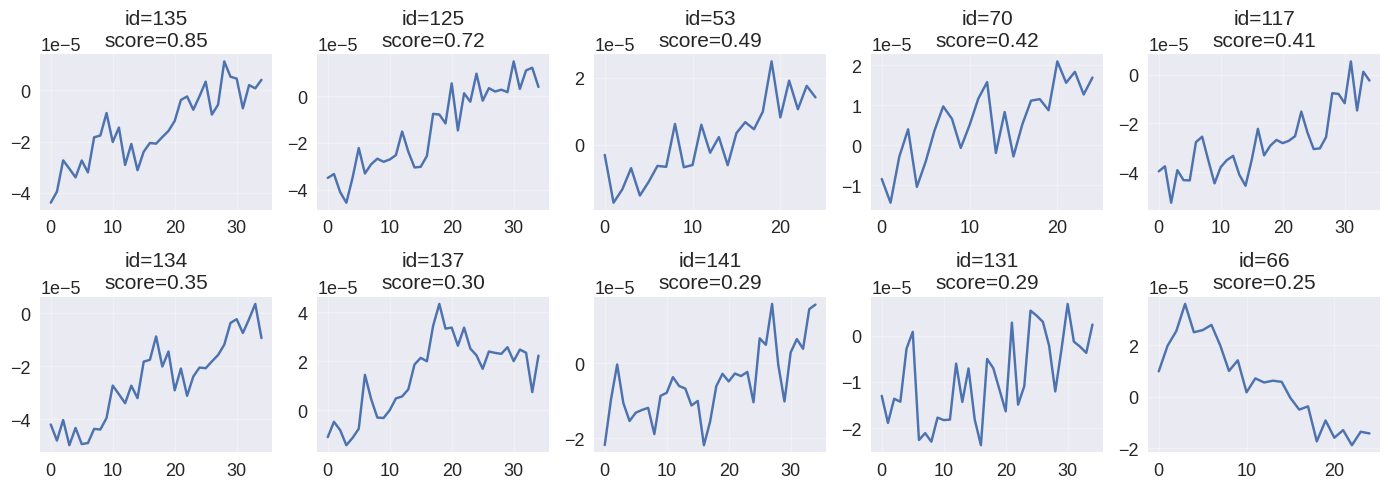

In [17]:
# Manual shapelet pipeline: candidates -> distances -> scores -> classifier
from sklearn.ensemble import RandomForestClassifier

Xtr = X_train[:, 0, :].astype(float)
Xte = X_test[:, 0, :].astype(float)
ytr = np.asarray(y_train)
yte = np.asarray(y_test)

def z_norm(x, eps=1e-8):
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / (x.std() + eps)

def shapelet_distance(series, shapelet):
    s = z_norm(series)
    shp = z_norm(shapelet)
    w = len(shp)
    best = np.inf
    for i in range(len(s) - w + 1):
        window = z_norm(s[i:i + w])
        d = np.sqrt(np.mean((window - shp) ** 2))
        if d < best:
            best = d
    return float(best)

def evaluate_shapelet(shapelet, X, y):
    d = np.array([shapelet_distance(x, shapelet) for x in X], dtype=float)
    classes = np.unique(y)
    means = np.array([d[y == c].mean() for c in classes], dtype=float)
    global_mean = d.mean()
    ss_between = np.sum([(y == c).sum() * (m - global_mean) ** 2 for c, m in zip(classes, means)])
    ss_within = float(np.sum([np.sum((d[y == c] - m) ** 2) for c, m in zip(classes, means)]))
    return float(ss_between / (ss_within + 1e-8))

def generate_candidates(X, lengths=(15, 25, 35), per_length=40, random_state=0):
    rng = np.random.default_rng(random_state)
    n, m = X.shape
    cands = []
    for L in lengths:
        if L >= m:
            continue
        for _ in range(per_length):
            i = int(rng.integers(0, n))
            j = int(rng.integers(0, m - L + 1))
            cands.append(X[i, j:j + L].copy())
    return cands

candidates = generate_candidates(Xtr, lengths=(15, 25, 35), per_length=50, random_state=0)
scores = np.array([evaluate_shapelet(shp, Xtr, ytr) for shp in candidates], dtype=float)

top_k = 20
top_ids = np.argsort(scores)[-top_k:][::-1]
top_shapelets = [candidates[i] for i in top_ids]

print(f'Candidates generated: {len(candidates)}')
print(f'Selected top shapelets: {len(top_shapelets)}')
print('Top-5 scores:', np.round(scores[top_ids[:5]], 4))

Xtr_feat = np.column_stack([[shapelet_distance(x, shp) for x in Xtr] for shp in top_shapelets])
Xte_feat = np.column_stack([[shapelet_distance(x, shp) for x in Xte] for shp in top_shapelets])

rf = RandomForestClassifier(n_estimators=300, random_state=0)
rf.fit(Xtr_feat, ytr)
pred_rf = rf.predict(Xte_feat)

print('\nManual shapelet-features classifier:')
print(classification_report(yte, pred_rf))

fig, axes = plt.subplots(2, 5, figsize=(14, 5))
axes = axes.ravel()
for ax, sid in zip(axes, top_ids[:10]):
    ax.plot(candidates[sid])
    ax.set_title(f'id={sid}\nscore={scores[sid]:.2f}')
    ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
